### Extracting the Principal Components Step by Step

Let's start by doing the first 4 steps of PCA:
- Standardizing the data
- Constructing the covariance matrix
- Obtaining the eigenvalues and eigenvectors of the covariance matrix
- Sorting the eigenvalues by decreasing order to rank the eigenvectors

In [1]:
import pandas as pd
df_wine = pd.read_csv('wine.data', header=None)
df_wine.columns = ['Class label', 'Alcohol',
                   'Malic acid', 'Ash', 
                   'Alcalinity of ash', 'Magnesium', 
                   'Total phenols', 'Flavanoids',
                   'Nonflavanoid phenols', 
                   'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines', 
                   'Proline']

from sklearn.model_selection import train_test_split
X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    stratify=y,
                                                    random_state=0)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

The first step is complete, now we need to construct the covariance matrix. This d by d-dimensional matrix stores the pairwise covariances between the different features. A positive covariance means the two features increase or decrease together, whereas a negative covariance indicates that the features vary in opposite directions. The eigenvectors of the covariance matrix represent the principal components(the directions of maximum variance) and the corresponding eigenvalues will define their magnitude.

We will use linalg.eig function from Numpy to obtain eigenpairs of the Wine covariance matrix:

In [2]:
import numpy as np
cov_mat = np.cov(X_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)
print('\nEigenvalues \n', eigen_vals)



Eigenvalues 
 [4.84274532 2.41602459 1.54845825 0.96120438 0.84166161 0.6620634
 0.51828472 0.34650377 0.3131368  0.10754642 0.21357215 0.15362835
 0.1808613 ]


### Total and Explained Variance

Let's now calculate the cumulative sum of the explained variances and plot it:

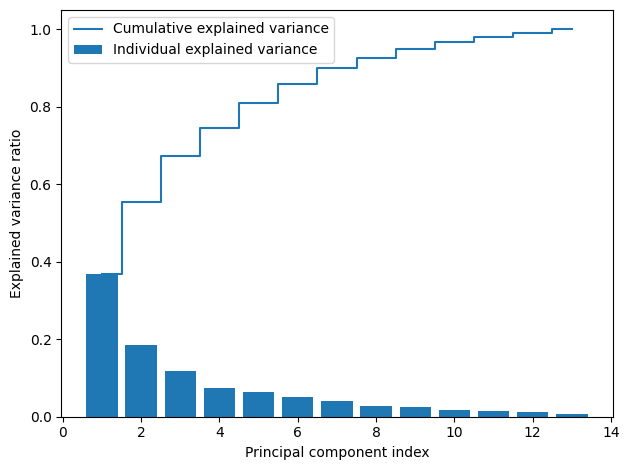

In [3]:
tot = sum(eigen_vals)
var_exp = [(i/tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

import matplotlib.pyplot as plt
plt.bar(range(1, 14), var_exp, align='center', label='Individual explained variance')
plt.step(range(1, 14), cum_var_exp, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

The plot indicates that the first principal component alone accounts for approximately 40 percent of the variance, and the first two principal components combined account for almost 60 percent of the variance in the dataset.

### Feature Transformation

Now that we have decomposed the covariance matrix into eigenpairs, let's proceed with the remaining 3 steps:
- Select k largest eigenvectors
- Construct a projection matrix $\mathbf{W}$ from the top k eigenvectors
- Transform the d-dimensional input data using the projection matrix $\mathbf{W}$ to obtain the new k-dimensional feature subspace

In [4]:
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i]) for i in range(len(eigen_vals))]
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

Let's collect the first two eigenvectors to capture 60% of the variance in the dataset:

In [5]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis],
               eigen_pairs[1][1][:, np.newaxis]))

print('Matrix W:\n', w)

Matrix W:
 [[-0.13724218  0.50303478]
 [ 0.24724326  0.16487119]
 [-0.02545159  0.24456476]
 [ 0.20694508 -0.11352904]
 [-0.15436582  0.28974518]
 [-0.39376952  0.05080104]
 [-0.41735106 -0.02287338]
 [ 0.30572896  0.09048885]
 [-0.30668347  0.00835233]
 [ 0.07554066  0.54977581]
 [-0.32613263 -0.20716433]
 [-0.36861022 -0.24902536]
 [-0.29669651  0.38022942]]


Using the projection matrix, we can transform an example row vector (13-dimensional), onto the PCA subspace (the principal components one and two). We can also transform the entire 124 $\times$ 13-dimensional training dataset onto the two principal components by calculating the matrix dot product:

In [6]:
X_train_std[0].dot(w)
X_train_pca = X_train_std.dot(w)

Using two principal components allows us to visualize the transformed Wine training dataset easily:

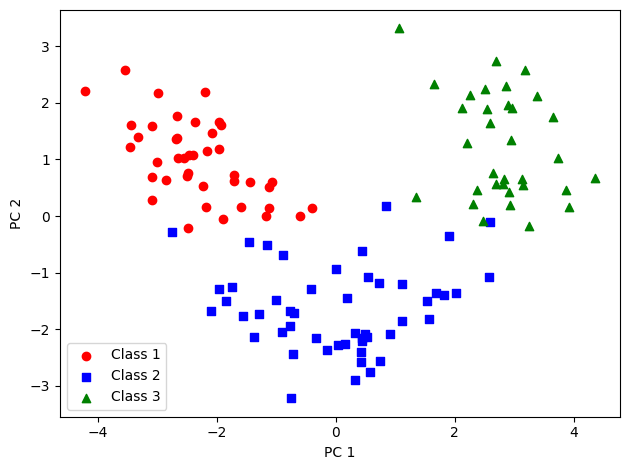

In [7]:
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']
for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train == l, 0],
                X_train_pca[y_train == l, 1],
                c=c, marker=m, label=f'Class {l}')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

As we can see, the data is more spread along the first principal component than the second principal component, which is consistent with the explained variance ratio plot that we created in the previous subsection. However, we can tell that a linear classifier will likely be able to separate the classes well.

### Principal Component Analysis in scikit-learn

We will now go through the scikit-learn implementation of the PCA class. Let's start with bringing back our decision region plotting function from Chapter 2:

In [8]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):
    """
    Plot 2D decision regions for a trained classifier.

    Parameters
    ----------
    X : array-like of shape (n_samples, 2)
        Feature matrix with exactly 2 columns.
    y : array-like of shape (n_samples,)
        Class labels.
    classifier : object
        Trained model with a .predict() method.
    resolution : float
        Step size for the background grid.
    """

    # Visual style for each class
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    unique_classes = np.unique(y)
    cmap = ListedColormap(colors[:len(unique_classes)])

    # Determine plot boundaries from the data
    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1
    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    # Create a dense grid of coordinates covering the whole plot area
    x_values = np.arange(x_min, x_max, resolution)
    y_values = np.arange(y_min, y_max, resolution)
    grid_x, grid_y = np.meshgrid(x_values, y_values)

    # Convert the grid into a list of points:
    # [[x1, y1], [x2, y2], [x3, y3], ...]
    grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel()))

    # Predict a class for every point in the grid
    grid_predictions = classifier.predict(grid_points)

    # Turn the 1D predictions back into the 2D grid shape
    decision_map = grid_predictions.reshape(grid_x.shape)

    # Draw the colored decision regions
    plt.contourf(grid_x, grid_y, decision_map, alpha=0.3, cmap=cmap)
    plt.xlim(grid_x.min(), grid_x.max())
    plt.ylim(grid_y.min(), grid_y.max())

    # Plot the actual data points on top
    for class_index, class_label in enumerate(unique_classes):
        plt.scatter(
            X[y == class_label, 0],
            X[y == class_label, 1],
            alpha=0.8,
            c=colors[class_index],
            marker=markers[class_index],
            label=f"Class {class_label}",
            edgecolor="black"
        )


Now, let's use the PCA class from scikit-learn on the Wine training dataset, classify the transformed examples via logistic regression, and visualize the decision regions via the plot_decision_regions function:

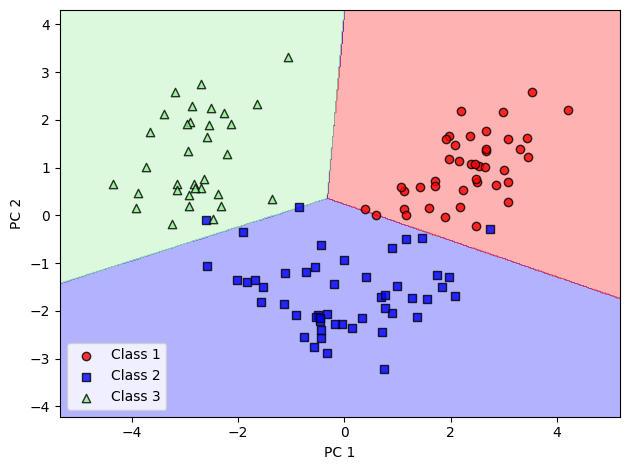

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
lr = OneVsRestClassifier(LogisticRegression(solver='lbfgs', 
                                            random_state=1))

X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

lr.fit(X_train_pca, y_train)
plot_decision_regions(X_train_pca, y_train, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Let's also plot the decision regions for the test dataset for completeness:

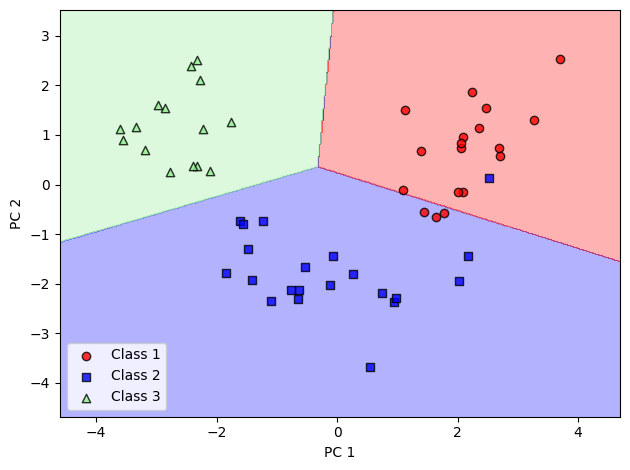

In [10]:
plot_decision_regions(X_test_pca, y_test, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

### Assessing Feature Contributions

Let's compute the 13 $\times$ 13 dimensional loadings matrix by multiplying the eigenvectors by the square root of the eigenvalues:

In [11]:
loadings = eigen_vecs * np.sqrt(eigen_vals)

Then, we can plot the loadings for the first principal component, which is the first column in this matrix:

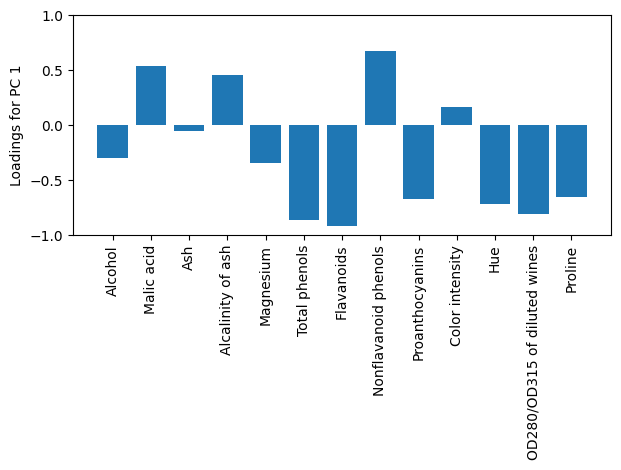

In [12]:
fig, ax = plt.subplots()
ax.bar(range(13), loadings[:, 0], align='center')
ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)
plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

We can see that alcohol has a negative correlation with the first principal component whereas malic acid has a positive correlation. These factor loadings were for our own PCA implementation, we can obtain the loadings form a fitted scikit-learn PCA object in a similar way:

In [13]:
sklearn_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

Let us recreate the bar plot using these loadings now:

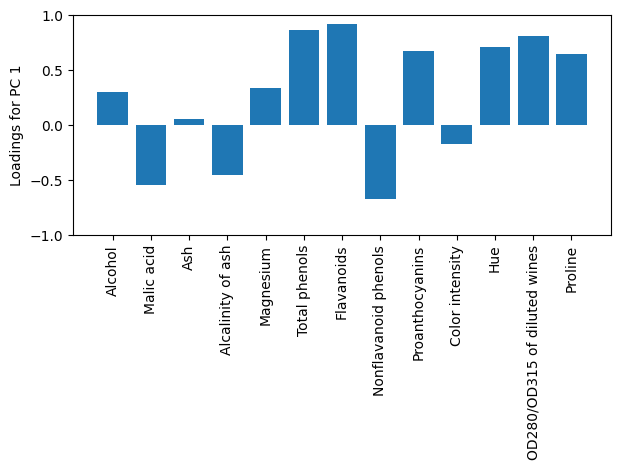

In [15]:
fig, ax = plt.subplots()
ax.bar(range(13), sklearn_loadings[:, 0], align='center')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)
ax.set_ylabel('Loadings for PC 1')
plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

### Supervised Data Compression via Linear Discriminant Analysis